# **Problem Statement (White Wine Quality Prediction)**

The objective of this project is to build a predictive modeling system that estimates the quality of white wine based on its physicochemical attributes. The dataset consists of measurable chemical properties such as acidity levels, sugar concentration, sulfur dioxide levels, chlorides, density, pH, alcohol percentage, and other factors that influence the sensory perception and quality rating of white wine.

White wine quality is typically assessed by expert tasters on a numerical scale, but the scoring is influenced by nonlinear interactions among the chemical components. As a result, predicting quality from physicochemical inputs represents a non-trivial regression problem.

This project aims to thoroughly analyze the dataset, explore feature relationships, and develop models that accurately predict white wine quality.

# Wine Quality Modeling Notebook


## **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

df=pd.read_csv('winequality-white.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


# **Checking for Null Values**

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


**Plotting a HeatMap to understand how each features contributes towards the Target**

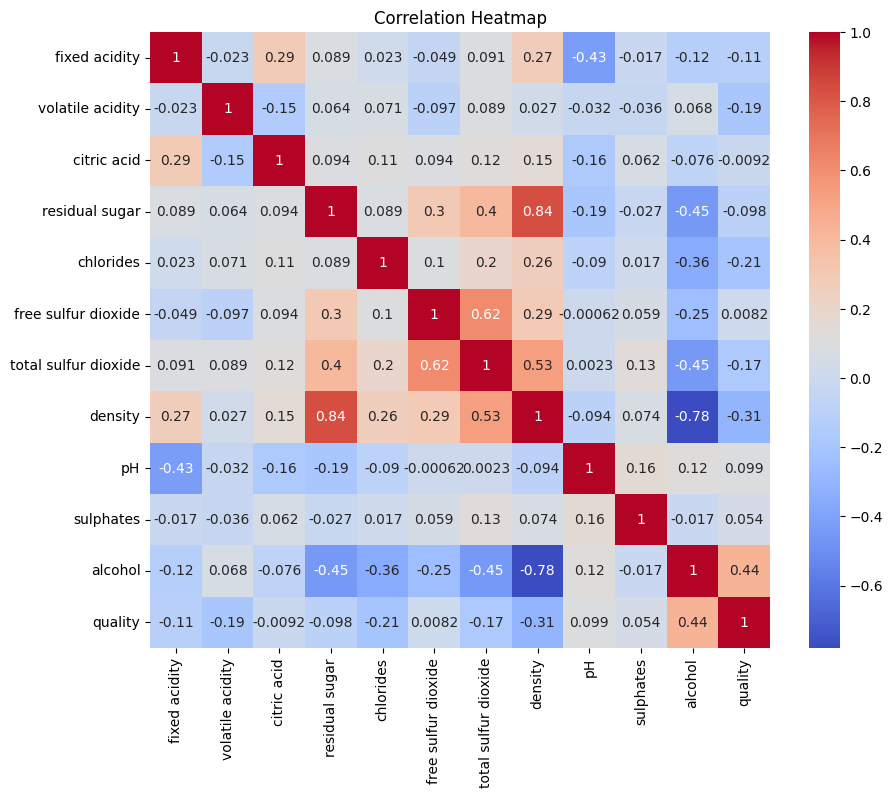

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# **Insights found from Heatmap Analysis**

1.Alcohol is the strongest positive predictor of wine quality (+0.44).

2.Volatile acidity and density negatively impact quality.

3.Residual sugar and density have extremely high correlation, indicating feature redundancy.

4.Sulfur dioxide components are strongly correlated with each other but weakly correlated with quality.

5.Overall correlations with the target are low, meaning nonlinear models are more suitable, which aligns with RF and NN performing better.





## Target Selection
Quality treated as regression.

In [ ]:
TARGET='quality'
X=df.drop(columns=[TARGET])
y=df[TARGET].astype(float)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)

## Model 1: Linear Regression – 3 Configurations

In [ ]:
from math import sqrt

configs = [
    {'fit_intercept': True},
    {'fit_intercept': False},
    {'positive': True}
]

models = []

for i, c in enumerate(configs):
    m = LinearRegression(**c)
    m.fit(X_train_s, y_train)

    pred = m.predict(X_test_s)

    mse = mean_squared_error(y_test, pred)
    rmse = sqrt(mse)

    print(f'Config {i+1} RMSE:', rmse)
    models.append(m)



Config 1 RMSE: 0.754337306334198
Config 2 RMSE: 5.930416796551461
Config 3 RMSE: 0.7865561218995231


## Model 2: RandomForestRegressor – 3 Configurations

In [ ]:
from math import sqrt

rf_configs = [
    {'n_estimators': 50},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': None}
]

for i, c in enumerate(rf_configs):
    m = RandomForestRegressor(**c, random_state=42)
    m.fit(X_train_s, y_train)
    pred = m.predict(X_test_s)

    mse = mean_squared_error(y_test, pred)
    rmse = sqrt(mse)

    print(f'RF Config {i+1} RMSE:', rmse)


RF Config 1 RMSE: 0.5929703850539422
RF Config 2 RMSE: 0.6424169243224368
RF Config 3 RMSE: 0.5876154250486469


## Neural Network – 3 Configurations

In [ ]:
from math import sqrt

nn_configs=[
    [64,32],
    [128,64,32],
    [256,128,64]
]

for i, layer_conf in enumerate(nn_configs):
    model = Sequential()
    for units in layer_conf:
        model.add(Dense(units, activation='relu'))

    model.add(Dense(1))
    model.compile(optimizer=Adam(0.001), loss='mse')

    model.fit(X_train_s, y_train, epochs=5, batch_size=32, verbose=0)

    pred = model.predict(X_test_s)

    mse = mean_squared_error(y_test, pred)
    rmse = sqrt(mse)

    print(f'NN Config {i+1} RMSE:', rmse)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
NN Config 1 RMSE: 0.9816107034252742
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
NN Config 2 RMSE: 0.7745662803017052
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
NN Config 3 RMSE: 0.7672896710884608
